ref - Wu, P., Eriksson, G., Pelton, A.D., 1993. Critical Evaluation and Optimization of the Thermodynamic Properties and Phase Diagrams of the CaO–FeO, CaO–MgO, CaO–MnO, FeO–MgO, FeO–MnO, and MgO–MnO Systems. Journal of the American Ceramic Society 76, 2065–2075. https://doi.org/10.1111/j.1151-2916.1993.tb08334.x

In [1]:
import matplotlib.pyplot as plt
import pycalphad.variables as v
from pycalphad import Database, binplot

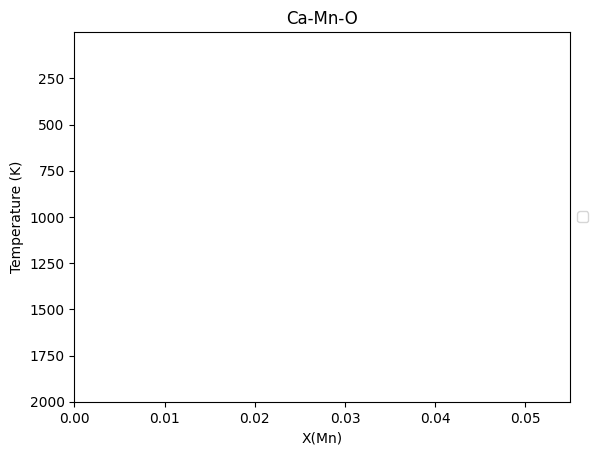

In [15]:
dbf = Database("CaO-MnO.xml")
comps = ["CA", "MN", "O"]
phases = dbf.phases.keys()

binplot(
    dbf,
    comps,
    phases,
    {
        v.N: 1,
        v.P: 101325,
        v.T: (2000, 3000, 5),
        v.X("MN"): (0, 0.5, 0.02),
        v.X("O"): 0.5,
    },
)
plt.show()

## 用 equilibrium 网格图查看相稳定区

这个单元不画相界线，而是在 T-X 网格上逐点做平衡计算，统计每个网格点的稳定相。

- 左图：稳定相个数（单相区/两相区）
- 右图：主稳定相（第一个非空相）的分布

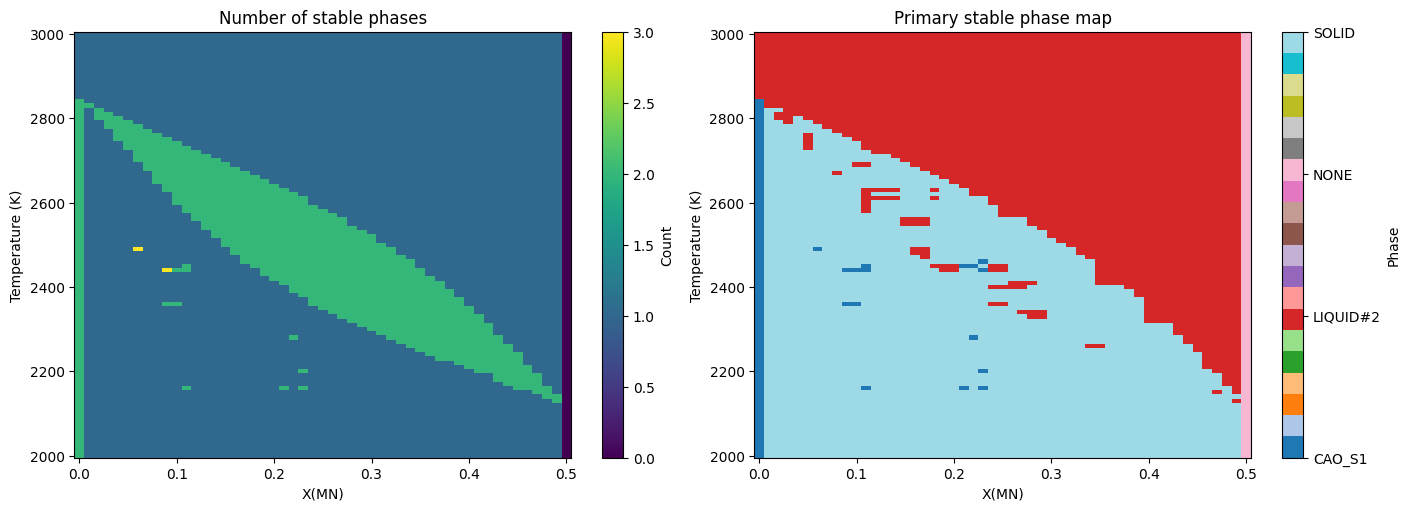

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pycalphad.variables as v
from pycalphad import equilibrium, Database

# 1) 数据库与计算条件
dbf = Database("CaO-MnO.xml")
comps = ["CA", "MN", "O"]
phases = list(dbf.phases.keys())

T_grid = np.arange(2000, 3000 + 1, 10)
XMN_grid = np.linspace(0.0, 0.5, 51)

# 2) 一次性做网格平衡计算（按维度名索引更稳健）
eq = equilibrium(
    dbf,
    comps,
    phases,
    {
        v.N: 1,
        v.P: 101325,
        v.T: T_grid,
        v.X("MN"): XMN_grid,
        v.X("O"): 0.5,
    },
)

phase_arr = eq.Phase.isel(N=0, P=0, X_O=0).values  # 形状: (T, X_MN, vertex)

# 3) 提取每个网格点的稳定相信息
nT = len(T_grid)
nX = len(XMN_grid)
num_stable = np.zeros((nT, nX), dtype=int)
first_phase = np.empty((nT, nX), dtype=object)

for i in range(nT):
    for j in range(nX):
        raw = phase_arr[i, j, :]
        plist = [str(p) for p in raw if str(p) not in ("", "nan")]
        num_stable[i, j] = len(plist)
        first_phase[i, j] = plist[0] if plist else "NONE"

# 4) 图1：稳定相个数（1=单相，2=两相...）
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

im0 = axes[0].pcolormesh(
    XMN_grid, T_grid, num_stable, shading="nearest", cmap="viridis"
)
axes[0].set_title("Number of stable phases")
axes[0].set_xlabel("X(MN)")
axes[0].set_ylabel("Temperature (K)")
cbar0 = fig.colorbar(im0, ax=axes[0])
cbar0.set_label("Count")

# 5) 图2：主稳定相分类图
phase_names = sorted(set(first_phase.ravel()))
phase_to_id = {p: k for k, p in enumerate(phase_names)}
phase_id = np.vectorize(phase_to_id.get)(first_phase)

im1 = axes[1].pcolormesh(XMN_grid, T_grid, phase_id, shading="nearest", cmap="tab20")
axes[1].set_title("Primary stable phase map")
axes[1].set_xlabel("X(MN)")
axes[1].set_ylabel("Temperature (K)")

cbar1 = fig.colorbar(im1, ax=axes[1], ticks=np.arange(len(phase_names)))
cbar1.ax.set_yticklabels(phase_names)
cbar1.set_label("Phase")

plt.show()